In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

from bio_network.engine.neurons import IzhikevichPopulation
from bio_network.engine.scheduler import simulate
from bio_network.engine.synapses_sparse import SparseSynapses
from bio_network.senses import InputProjection, LabelsReadout, Retina, RetinaStimulus
from bio_network.senses.mnist import load_mnist, subsample_mnist

N_EXC, N_INH = 800, 200
N = N_EXC + N_INH
SEED = 42
GAIN = 8.0
OUT_DEGREE = 100
WINDOW_MS = 350.0
GAP_MS = 150.0
FANOUT = 20
OUTPUT_DIR = os.path.join(os.getcwd(), "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output directory:", OUTPUT_DIR)


Output directory: A:\Bio Network\notebooks\output


# Milestone 3.2 -- a plastic input projection ("optic nerve")

M3 v1 froze the input cable: every retina pixel drove a fixed random fan-out of
neurons through unit weight, so a neuron's receptive field was a static cocktail
of uncorrelated pixels and the readout collapsed. This notebook runs the M3.2
controlled experiment: make the input projection **plastic** (`w_in in [0,1]`,
init uniform 0.2-0.4, STDP tau 20 ms, A+ 0.10, A- 0.12, frozen at
assignment/test) and compare against the identical seed/topology control arm.

Honesty rules:

- the two arms differ ONLY in input plasticity (same seeds, fan-out, images);
- plasticity is phase-gated (training only; frozen at assignment/test);
- both readouts (soft prototype and per-neuron plurality vote) are committed
  up-front and both reported;
- numbers are reported as they land, however small or absent the effect.


In [2]:
def per_image_response(stim, rec):
    R = np.zeros((len(stim), N), dtype=np.int64)
    for i in range(len(stim)):
        t0, t1 = stim.slot_boundaries(i)
        m = (rec.times_ms >= t0) & (rec.times_ms < t1)
        R[i] = np.bincount(rec.indices[m], minlength=N)
    return R


def run_arm(imgs, test_imgs, plastic):
    """Full train -> assignment -> test protocol for ONE arm."""
    retina = Retina(seed=SEED, window_ms=WINDOW_MS)
    proj = InputProjection(28 * 28, N, fanout=FANOUT, seed=SEED, plastic=plastic)
    pop = IzhikevichPopulation(seed=SEED)
    syn = SparseSynapses(
        n_excit=N_EXC, n_inhib=N_INH, out_degree=OUT_DEGREE, seed=SEED, gain=GAIN
    )
    input_fn = proj.on_neurons_fired if plastic else None

    # TRAIN (STDP on; input plasticity on iff this arm); discard training resp.
    tr_stim = RetinaStimulus(retina, proj, imgs, gap_ms=GAP_MS)
    rec_train = simulate(
        pop, syn, T_ms=int(len(imgs) * tr_stim.slot_ms), engine="sparse",
        seed=SEED, learning=True, stimulus_fn=tr_stim, input_plastic_fn=input_fn,
    )
    # ASSIGNMENT (frozen) on the SAME training images -- labels used here only.
    as_stim = RetinaStimulus(retina, proj, imgs, gap_ms=GAP_MS)
    rec_asgn = simulate(
        pop, syn, T_ms=int(len(imgs) * as_stim.slot_ms), engine="sparse",
        seed=SEED, learning=False, stimulus_fn=as_stim, input_plastic_fn=None,
    )
    # TEST (frozen) on held-out images.
    te_stim = RetinaStimulus(retina, proj, test_imgs, gap_ms=GAP_MS)
    rec_test = simulate(
        pop, syn, T_ms=int(len(test_imgs) * te_stim.slot_ms), engine="sparse",
        seed=SEED, learning=False, stimulus_fn=te_stim, input_plastic_fn=None,
    )
    return {
        "proj": proj,
        "rec_train": rec_train,
        "resp_train": per_image_response(as_stim, rec_train),
        "resp_test": per_image_response(te_stim, rec_test),
        "test_imgs": test_imgs,
    }


def ria_tiles(imgs, resp):
    arr = np.stack([np.asarray(i) for i in imgs])
    denom = resp.sum(axis=0)
    tiles = np.zeros((resp.shape[1], *arr.shape[1:]))
    for n in range(resp.shape[1]):
        if denom[n] > 0:
            tiles[n] = np.tensordot(resp[:, n], arr, axes=(0, 0)) / denom[n]
    return tiles


def structured_count(tiles, max_frac=0.05):
    c = 0
    for t in tiles:
        m = t.max()
        if m > 0 and (t >= 0.5 * m).mean() <= max_frac:
            c += 1
    return c


In [3]:
x_train, y_train, x_test, y_test = load_mnist()
x_train, y_train = subsample_mnist(x_train, y_train, per_class=12)
x_test, y_test = subsample_mnist(x_test, y_test, per_class=6)
train_imgs = [np.asarray(i, dtype=float) / 255.0 for i in x_train]
test_imgs = [np.asarray(i, dtype=float) / 255.0 for i in x_test]
train_labels = y_train.astype(np.int64)
test_labels = y_test.astype(np.int64)
print("train:", x_train.shape, " test:", x_test.shape)


train: (120, 28, 28)  test: (60, 28, 28)


## E32a/E32b -- the arm is architecture-identical; only weight mode differs

Build the frozen and plastic projections from the same seed: the topology
(targets, per-neuron fan-in) is byte-identical, `drive_weights` is ones when
frozen and `w_in` when plastic, and the plastic arm is homeostatically
balanced so its total drive equals the frozen arm's.


In [4]:
proj_c = InputProjection(28 * 28, N, fanout=FANOUT, seed=SEED, plastic=False)
proj_p = InputProjection(28 * 28, N, fanout=FANOUT, seed=SEED, plastic=True)
print("targets identical:", bool(np.array_equal(proj_c.targets, proj_p.targets)))
print("fan-in mean/std:", round(proj_c.fan_in_stats()[0], 2),
      round(proj_c.fan_in_stats()[1], 2))
print("frozen drive (all one):", float(proj_c.drive_weights(np.array([0, 1])).mean()))
print("plastic w_in init: [%.3f, %.3f]" % (proj_p._weights_flat.min(), proj_p._weights_flat.max()))
print("plastic homeostatic drive mean ~1.0:",
      round(float(proj_p.drive_weights(np.arange(784)).mean()), 3))


targets identical: True
fan-in mean/std: 15.68 3.88
frozen drive (all one): 1.0
plastic w_in init: [0.200, 0.400]
plastic homeostatic drive mean ~1.0: 1.0


## E32c -- end-to-end readout (the two arms above, in full)

Each arm does: train (STDP, input plastic iff this arm), frozen assignment on
the training split (labels used here only), frozen prediction on the held-out
split. Two pre-committed readouts are fit from the assignment responses.


In [5]:
results = {}

for plastic in (False, True):
    name = "control" if not plastic else "plastic"
    results[name] = run_arm(train_imgs, test_imgs, plastic)
    print(f"{name}: train spikes {results[name]['rec_train'].times_ms.size}, "
          f"rate {results[name]['rec_train'].mean_rates_hz().mean():.2f} Hz")


control: train spikes 314800, rate 5.25 Hz


plastic: train spikes 45517, rate 0.76 Hz


## E32c -- the readout, both decoders, both arms

Both the soft prototype classifier (`predict`) and the hard per-neuron
plurality vote (`predict_vote`) are fit on the *training* assignment responses
and evaluated on the held-out test responses. Both numbers are reported, for
both arms.


In [6]:
acc_soft, acc_vote = {}, {}
readouts = {}
for name in ("control", "plastic"):
    ro = LabelsReadout(n_neurons=N, n_classes=10)
    ro.fit(results[name]["resp_train"], train_labels)
    readouts[name] = ro
    resp = results[name]["resp_test"]
    acc_soft[name] = float(np.mean(ro.predict(resp) == test_labels))
    acc_vote[name] = float(np.mean(ro.predict_vote(resp) == test_labels))
    print(f"{name}: soft {acc_soft[name]:.3f}  vote {acc_vote[name]:.3f}")


control: soft 0.200  vote 0.100
plastic: soft 0.100  vote 0.100


## E32 visual -- accuracy bars and prediction histogram


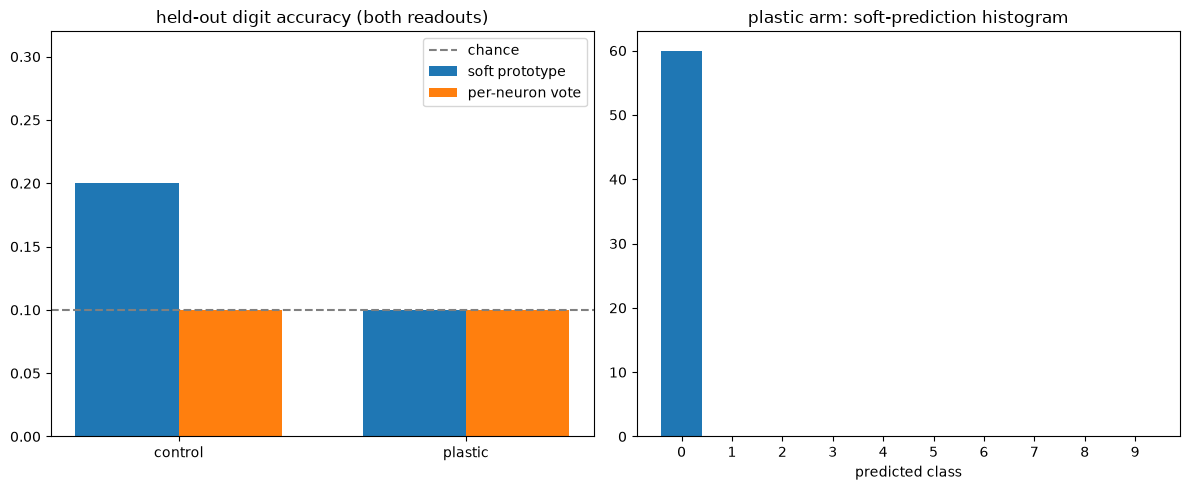

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names = ["control\nfrozen", "plastic\nlearned"]
soft = [acc_soft["control"], acc_soft["plastic"]]
vote = [acc_vote["control"], acc_vote["plastic"]]
x = np.arange(2)
axes[0].bar(x - 0.18, soft, 0.36, label="soft prototype")
axes[0].bar(x + 0.18, vote, 0.36, label="per-neuron vote")
axes[0].axhline(0.10, color="gray", ls="--", label="chance")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["control", "plastic"])
axes[0].set_ylim(0, min(1.0, max(max(soft), max(vote)) * 1.6))
axes[0].set_title("held-out digit accuracy (both readouts)")
axes[0].legend()

pred_p = readouts["plastic"].predict(results["plastic"]["resp_test"])
hist = np.bincount(pred_p, minlength=10)
axes[1].bar(np.arange(10), hist)
axes[1].set_xticks(np.arange(10))
axes[1].set_title("plastic arm: soft-prediction histogram")
axes[1].set_xlabel("predicted class")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "m32_accuracy_bars.png"), dpi=110)
plt.show()


# E32b -- receptive-field tiles, control vs plastic

For each arm, compute the **RIA** receptive-field images from its frozen test
responses and rank tiles by peak activation. Count 'structured' tiles (bright
pixels concentrated on <= 5% of the image): the Diehl & Cook signature of a
localized receptive field.


control: structured tiles 0
plastic: structured tiles 0


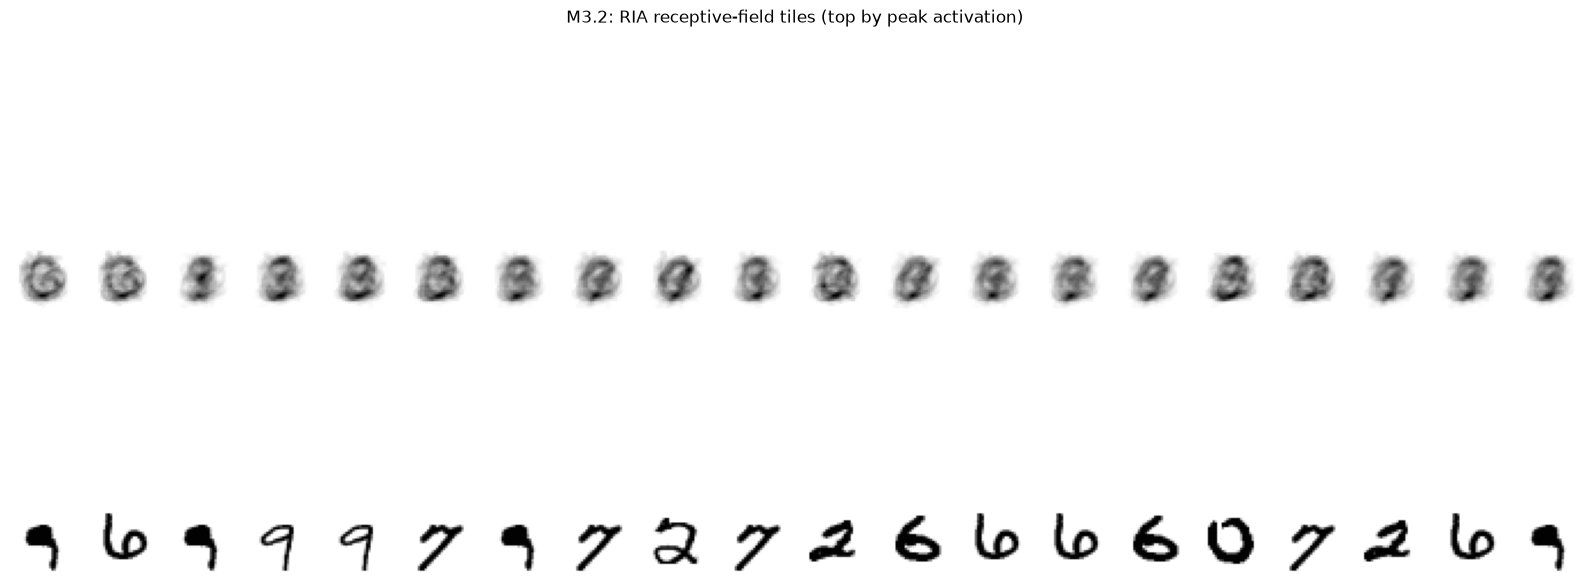

[saved] A:\Bio Network\notebooks\output\m32_tiles_diptych.png


In [8]:
tiles = {}
for name in ("control", "plastic"):
    resp = results[name]["resp_test"]
    tiles[name] = ria_tiles(test_imgs, resp)
    print(f"{name}: structured tiles {structured_count(tiles[name])}")

fig, axes = plt.subplots(2, 20, figsize=(16, 8))
for row, name in enumerate(("control", "plastic")):
    t = tiles[name]
    spec = t.reshape(t.shape[0], -1).max(axis=1)
    order = np.argsort(spec)[::-1]
    for k in range(20):
        ax = axes[row, k]
        n = order[k]
        if spec[n] > 1e-9:
            ax.imshow(t[n], cmap="gray_r")
        ax.axis("off")
    axes[row, 0].set_ylabel(name.title(), fontsize=12)
fig.suptitle("M3.2: RIA receptive-field tiles (top by peak activation)")
fig.tight_layout()
out = os.path.join(OUTPUT_DIR, "m32_tiles_diptych.png")
fig.savefig(out, dpi=90)
plt.show()
print("[saved]", out)


## Take-away

Report the numbers exactly as measured: control vs plastic held-out accuracy
(soft and vote readouts) and the tile statistics. The scientific question is
whether the plastic input pathway produces structured, digit-like receptive
fields and better recognition -- and the answer should be reported honestly
even if the effect is absent (e.g. the plastic arm starves the network when LTD
A- 0.12 outweighs LTP A+ 0.10 at the observed firing rate). The notebook-scale
run above mirrors the full protocol in `benchmarks/m32_plastic_optic_nerve.py`
and the numbers it prints here are color-comparable to `docs/M3_2_RESULTS.md`.
